<center><img src="https://raw.githubusercontent.com/open-edge-platform/anomalib/main/docs/source/_static/images/logos/anomalib-wide-blue.png" alt="Paris" class="center"></center>

<center>💙 A library for benchmarking, developing and deploying deep learning anomaly detection algorithms</center>

---

> NOTE:
> This notebook is originally created by @innat on [Kaggle](https://www.kaggle.com/code/ipythonx/mvtec-ad-anomaly-detection-with-anomalib-library/notebook).

[Anomalib](https://github.com/open-edge-platform/anomalib): Anomalib is a deep learning library that aims to collect state-of-the-art anomaly detection algorithms for benchmarking on both public and private datasets. Anomalib provides several ready-to-use implementations of anomaly detection algorithms described in the recent literature, as well as a set of tools that facilitate the development and implementation of custom models. The library has a strong focus on image-based anomaly detection, where the goal of the algorithm is to identify anomalous images, or anomalous pixel regions within images in a dataset.

The library supports a number of image and video datasets for **benchmarking** and custom dataset support for **training/inference**. In this notebook, we will explore `anomalib` training a PADIM model on the `MVTec AD` bottle dataset and evaluating the model's performance.


## Installing Anomalib


Installation can be done in two ways: (i) install via PyPI, or (ii) installing from sourc, both of which are shown below:


### I. Install via PyPI


In [ ]:
# Option - I: Uncomment the next line if you want to install via pip.
# %pip install anomalib
# %anomalib install -v

> NOTE:
>
> Although v1.0.0 is on PyPI, it may not be stable and may have bugs. It is therefore recommended to install from source.


### II. Install from Source

This option would initially download anomalib repository from github and manually install `anomalib` from source, which is shown below:


In [ ]:
# Option - II: Uncomment the next three lines if you want to install from the source.
# !git clone https://github.com/open-edge-platform/anomalib.git
# %cd anomalib
# %pip install .
# %anomalib install -v

Now let's verify the working directory. This is to access the datasets and configs when the notebook is run from different platforms such as local or Google Colab.


In [1]:
# %cd /home/admin_rech/repos/anomalib/examples/01_getting_started/
import os
from pathlib import Path

from git.repo import Repo
current_directory = Path.cwd()
print(f"Current directory: {current_directory}")
if current_directory.name == "01_getting_started":
    # On the assumption that, the notebook is located in
    #   ~/anomalib/examples/notebooks/01_getting_started/
    root_directory = current_directory.parent.parent
elif current_directory.name == "anomalib":
    # This means that the notebook is run from the main anomalib directory.
    root_directory = current_directory
else:
    # Otherwise, we'll need to clone the anomalib repo to the `current_directory`
    repo = Repo.clone_from(
        url="https://github.com/open-edge-platform/anomalib.git",
        to_path=current_directory,
    )
    root_directory = current_directory / "anomalib"

os.chdir(root_directory)
print(f"Current working directory: {os.getcwd()}")

Current directory: /home/admin_rech/repos/anomalib/examples/01_getting_started
Current working directory: /home/admin_rech/repos/anomalib


## Imports


In [2]:
from typing import Any

import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from torchvision.transforms import ToPILImage

from anomalib.data import MVTecAD
from anomalib.data.utils import read_image
from anomalib.deploy import ExportType, OpenVINOInferencer
from anomalib.engine import Engine
from anomalib.models import Padim
from anomalib.utils.visualization import ImageResult

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Model

Currently, there are **13** anomaly detection models available in `anomalib` library. Namely,

- [CFA](https://arxiv.org/abs/2206.04325)
- [CS-Flow](https://arxiv.org/abs/2110.02855v1)
- [CFlow](https://arxiv.org/pdf/2107.12571v1.pdf)
- [DFKDE](https://github.com/open-edge-platform/anomalib/tree/main/anomalib/models/dfkde)
- [DFM](https://arxiv.org/pdf/1909.11786.pdf)
- [DRAEM](https://arxiv.org/abs/2108.07610)
- [FastFlow](https://arxiv.org/abs/2111.07677)
- [Ganomaly](https://arxiv.org/abs/1805.06725)
- [Padim](https://arxiv.org/pdf/2011.08785.pdf)
- [Patchcore](https://arxiv.org/pdf/2106.08265.pdf)
- [Reverse Distillation](https://arxiv.org/abs/2201.10703)
- [R-KDE](https://ieeexplore.ieee.org/document/8999287)
- [STFPM](https://arxiv.org/pdf/2103.04257.pdf)

In this tutorial, we'll be using [Padim](https://arxiv.org/pdf/2011.08785.pdf).


## Dataset: MVTec AD

**MVTec AD** is a dataset for benchmarking anomaly detection methods with a focus on industrial inspection. It contains over **5000** high-resolution images divided into **15** different object and texture categories. Each category comprises a set of defect-free training images and a test set of images with various kinds of defects as well as images without defects. If the dataset is not located in the root datasets directory, anomalib will automatically install the dataset.

We could now import the MVtec AD dataset using its specific datamodule implemented in anomalib.


In [3]:
datamodule = MVTecAD(num_workers=0)
datamodule.prepare_data()  # Downloads the dataset if it's not in the specified `root` directory
datamodule.setup()  # Create train/val/test/prediction sets.

i, data = next(enumerate(datamodule.val_dataloader()))
print(type(data))

<class 'anomalib.data.dataclasses.torch.image.ImageBatch'>


Let's check the shapes of the input images and masks.


In [4]:
print(data.image.shape, data.gt_mask.shape)

torch.Size([32, 3, 900, 900]) torch.Size([32, 900, 900])


We could now visualize a normal and abnormal sample from the validation set.


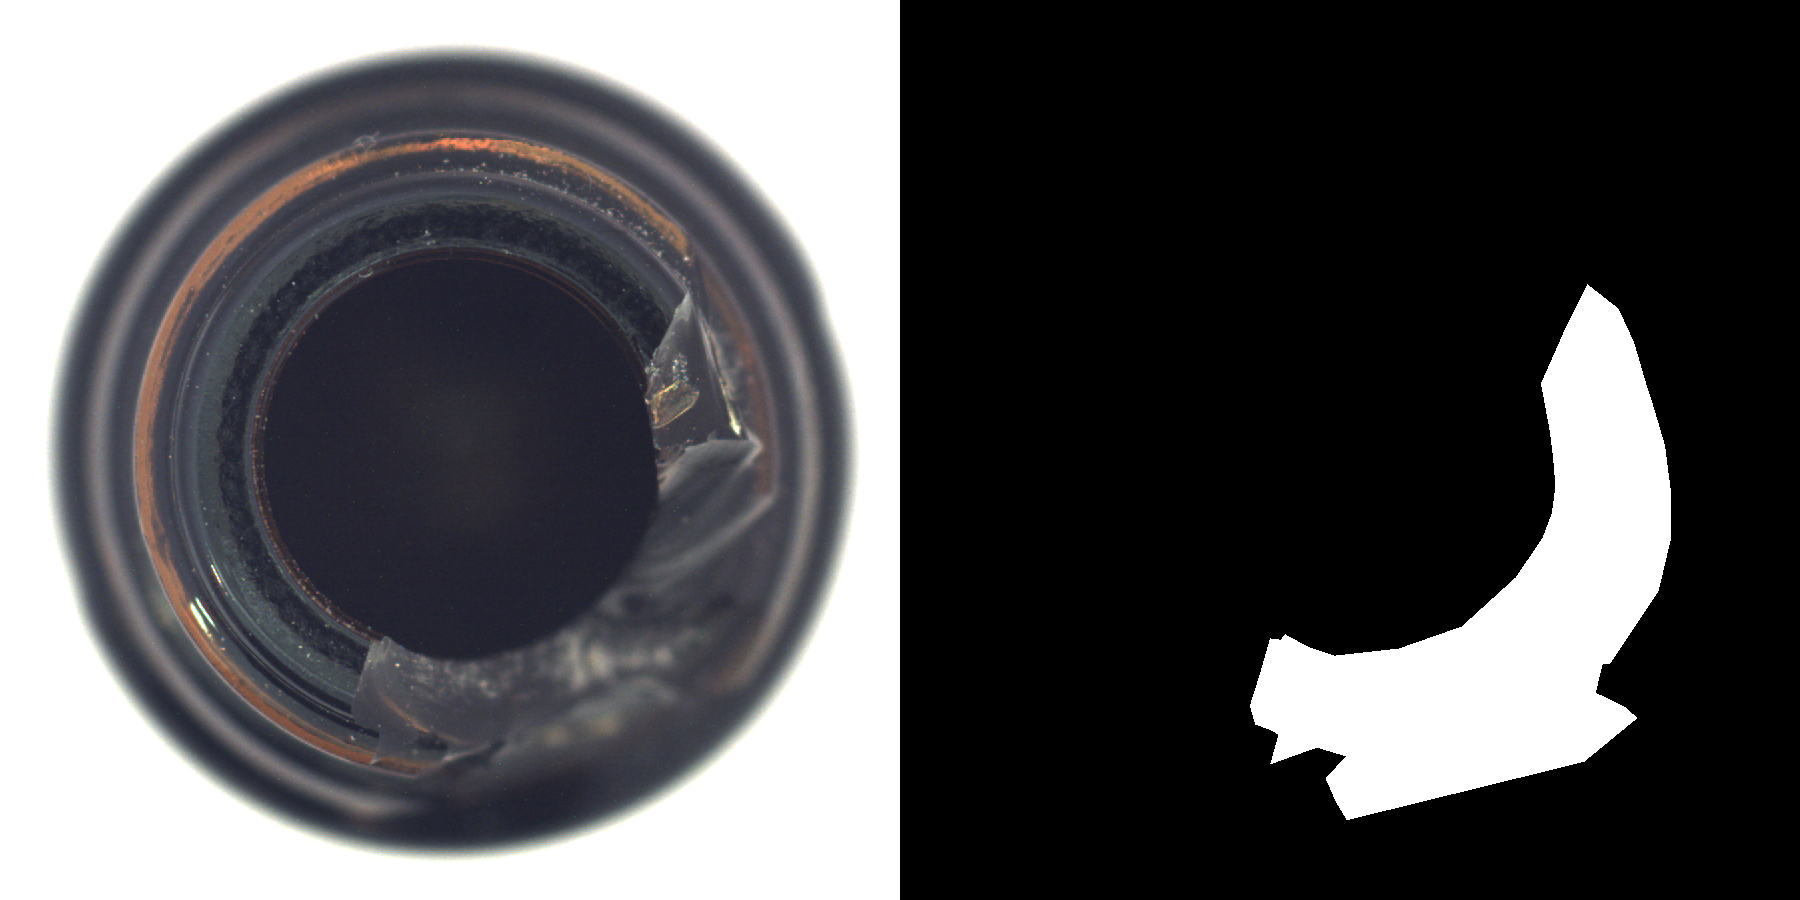

In [ ]:
def show_image_and_mask(sample: dict[str, Any], index: int) -> Image:
    """Show an image with a mask.

    Args:
        sample (dict[str, Any]): Sample from the dataset.
        index (int): Index of the sample.

    Returns:
        Image: Output image with a mask.
    """
    # Load the image from the path
    image = Image.open(sample.image_path[index])

    # Load the mask and convert it to RGB
    mask = ToPILImage()(sample.gt_mask[index].int()* 255).convert("RGB")

    # Resize mask to match image size, if they differ
    if image.size != mask.size:
        mask = mask.resize(image.size)

    return Image.fromarray(np.hstack((np.array(image), np.array(mask))))


# Visualize an image with a mask
show_image_and_mask(data, index=0)

## Prepare Model

Let's create the Padim and train it.


In [12]:
# Get the model and datamodule
model = Padim()
datamodule = MVTecAD(num_workers=0)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [13]:
# start training
engine = Engine()
engine.fit(model=model, datamodule=datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
You are using a CUDA device ('NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.p

`Trainer.fit` stopped: `max_epochs=1` reached.


## Validation


In [14]:
# load best model from checkpoint before evaluating
test_results = engine.test(
    model=model,
    datamodule=datamodule,
    ckpt_path=engine.trainer.checkpoint_callback.best_model_path,
)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at /home/admin_rech/repos/anomalib/results/Padim/MVTecAD/bottle/v0/weights/lightning/model.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/admin_rech/repos/anomalib/results/Padim/MVTecAD/bottle/v0/weights/lightning/model.ckpt


Output()

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │     0.997619092464447     │
│       image_F1Score       │    0.9841269850730896     │
│        pixel_AUROC        │     0.978436291217804     │
│       pixel_F1Score       │    0.6814129948616028     │
└───────────────────────────┴───────────────────────────┘

In [15]:
print(test_results)

[{'image_AUROC': 0.997619092464447, 'image_F1Score': 0.9841269850730896, 'pixel_AUROC': 0.978436291217804, 'pixel_F1Score': 0.6814129948616028}]


## OpenVINO Inference

Now that we trained and tested a model, we could check a single inference result using OpenVINO inferencer object. This will demonstrate how a trained model could be used for inference.


Before we can use OpenVINO inference, let's export the model to OpenVINO format first.


In [16]:
engine.export(
    model=model,
    export_type=ExportType.OPENVINO,
)

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1513: UserWarning: Provided key output for dynamic axes is not a valid input/output name
  _validate_dynamic_axes(dynamic_axes, model, input_names, output_names)
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/anomalib/post_processing/post_processor.py:333: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if not self._image_threshold.isnan():
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/anomalib/post_processing/post_processor.py:319: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated a

PosixPath('/home/admin_rech/repos/anomalib/results/Padim/MVTecAD/bottle/v0/weights/openvino/model.xml')

### Load a Test Image

Let's read an image from the test set and perform inference using OpenVINO inferencer.


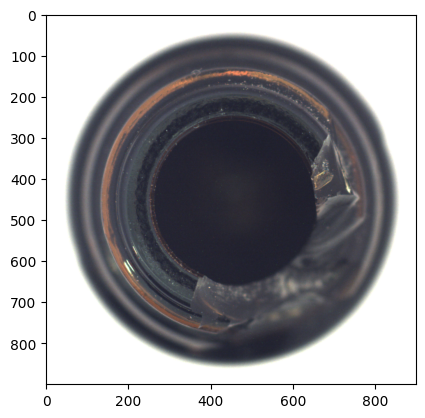

In [17]:
image_path = root_directory / "datasets/MVTecAD/bottle/test/broken_large/000.png"
image = read_image(path="./datasets/MVTecAD/bottle/test/broken_large/000.png")
plt.imshow(image)

### Load the OpenVINO Model

By default, the output files are saved into `results` directory. Let's check where the OpenVINO model is stored.


In [18]:
output_path = Path(engine.trainer.default_root_dir)
print(output_path)

/home/admin_rech/repos/anomalib/results/Padim/MVTecAD/bottle/v0


In [19]:
openvino_model_path = output_path / "weights" / "openvino" / "model.bin"
print(openvino_model_path.exists())

True


In [20]:
inferencer = OpenVINOInferencer(
    path=openvino_model_path,  # Path to the OpenVINO IR model.
    device="CPU",  # We would like to run it on an Intel CPU.
)

### Perform Inference

Predicting an image using OpenVINO inferencer is as simple as calling `predict` method.


In [21]:
predictions = inferencer.predict(image=image_path)
predictions = ImageResult.from_dataset_item(predictions.items[0])  # convert to imageresult for visualization

where `predictions` contain any inputs and outputs of the model, such as image, anomaly maps, predicted scores, labels or masks.


### Visualizing Inference Results


In [22]:
print(predictions.pred_score, predictions.pred_label)

0.7472784 True


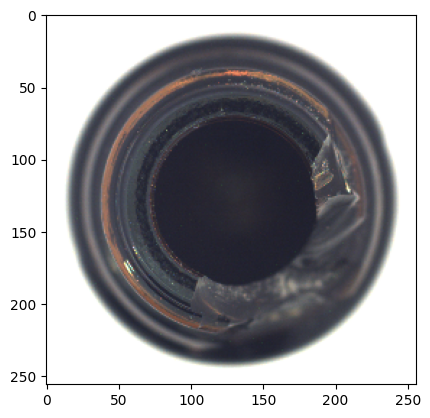

In [23]:
# Visualize the original image
plt.imshow(predictions.image)

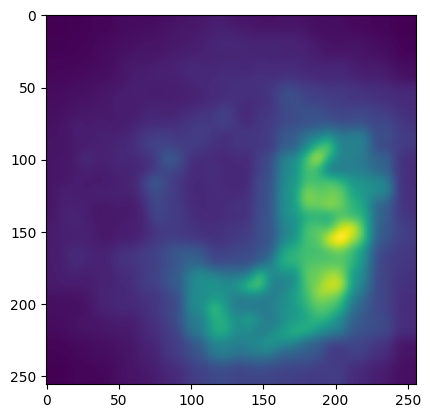

In [24]:
# Visualize the raw anomaly maps predicted by the model.
plt.imshow(predictions.anomaly_map)

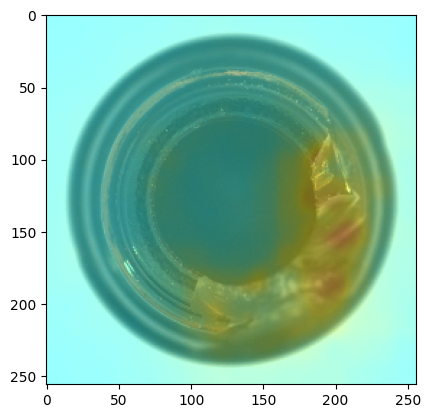

In [25]:
# Visualize the heatmaps, on which raw anomaly map is overlayed on the original image.
plt.imshow(predictions.heat_map)

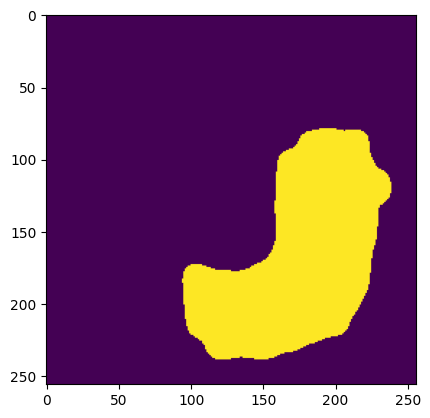

In [26]:
# Visualize the segmentation mask.
plt.imshow(predictions.pred_mask)

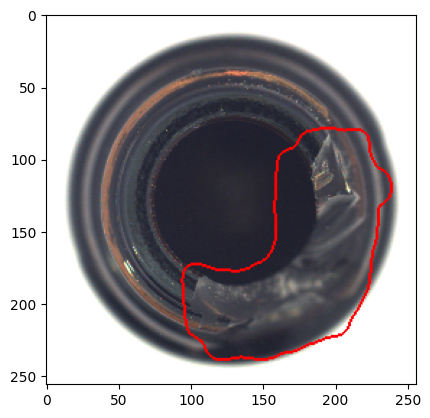

In [27]:
# Visualize the segmentation mask with the original image.
plt.imshow(predictions.segmentations)

This wraps the `getting_started` notebook. There are a lot more functionalities that could be explored in the library. Please refer to the [documentation](https://open-edge-platform.github.io/anomalib/) for more details.
